# Machine Learning Computer Lab: Jesse van der Ende

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Question 1
**In the (random design) linear regression framework where $Y = Z \theta^* + \epsilon$ (see the course for the
introduction of the precise notation), the expected excess risk bound was shown to scale as $\mathbb{E}[R(\hat{\theta})]−R(\theta^*) = \sigma^2(p + 1)/n$ where $\sigma^2$ is the variance noise, $n$ is the number of observation and $p$ is the
number of covariates. Using some computer experiments and considering a simulation set-up with
independent Gaussian covariates $X_i ∼N(0,I_p)$ where $I_p$ is identity matrix of size $p$ and Gaussian
noise $\epsilon_i ∼ N(0,\sigma^2)$, illustrate the previous statement (here the covariates are random). Formulas
from the course should be recalled and explained with care to make the illustration clear and sound.**

---

In the linear regression framework, one solution of the optimization problem is $\hat{\theta} = (Z^\top Z)^{-1}Z^\top Y$. I will work under the assumptions that ker(Z) = \{0\}, such that this $\hat{\theta}$ is the only optimal solution. Note that this assumption is needed for the excess risk bound to be valid.

From the slides, we have the following definitions of the empirical and the true risk:

$$
\widehat{R}_n(\theta) = \frac{1}{n} \sum_{i=1}^n (Y_i - Z_i^\top \theta)^2
$$
$$
R(\theta) = \frac{1}{n} \sum_{i=1}^n \mathbb{E}_{Y_i} \left[(Y_i - Z_i^\top \theta)^2\right]
$$

Since the $Z_i$ are now random, we can decompose the true risk into:
$$
\begin{align}
R(\theta) =& \frac{1}{n} \sum_{i=1}^n \mathbb{E}_{Y_i} \left[(Y_i - Z_i^\top \theta)^2\right] \\
          =& \frac{1}{n} \sum_{i=1}^n \mathbb{E}_{Y_i} \left[(Y_i - Z_i^\top \theta^* + Z_i^\top (\theta - \theta^*))^2\right] \\
          =& \frac{1}{n} \sum_{i=1}^n \mathbb{E}_{Y_i} \left[(\epsilon_i + Z_i^\top (\theta - \theta^*))^2\right] \\
          =& \frac{1}{n} \sum_{i=1}^n \mathbb{E}_{Y_i} \left[\epsilon_i^2 + 2 \epsilon_i Z_i^\top (\theta - \theta^*) + (Z_i^\top (\theta - \theta^*))^2\right] \\
          =& \frac{1}{n} \sum_{i=1}^n \mathbb{E}_{Y_i} \left[\epsilon_i^2\right] + 2 \mathbb{E}_{Y_i} \left[\epsilon_i Z_i^\top (\theta - \theta^*) \right]+ \mathbb{E}_{Y_i} \left[(Z_i^\top (\theta - \theta^*))^2\right] \\
          =& \frac{1}{n} \sum_{i=1}^n \sigma^2 + 2 \mathbb{E}_{Y_i} \left[\epsilon_i Z_i^\top (\theta - \theta^*) \right]+ \mathbb{E}_{Y_i} \left[(Z_i^\top (\theta - \theta^*))^2\right] \\

\end{align}
$$

Because everything is i.i.d., including the $\epsilon_i$ and $Z_i$, we have that $\mathbb{E}\left[ \epsilon_i Z_i^\top (\theta - \theta^*) \right] = \mathbb{E}\left[ \epsilon_i \right] \mathbb{E}\left[Z_i^\top (\theta - \theta^*) \right] = 0 \mathbb{E}\left[Z_i^\top (\theta - \theta^*) \right] = 0$. We then get that the true risk becomes:

$$
\begin{align}
R(\theta) =& \frac{1}{n} \sum_{i=1}^n \sigma^2 + \mathbb{E}_{Y_i} \left[(Z_i^\top (\theta - \theta^*))^2\right] \\
          =& \sigma^2 + \frac{1}{n} \sum_{i=1}^n \mathbb{E}_{Y_i} \left[(\theta - \theta^*)^\top Z_i Z_i^\top (\theta - \theta^*)\right] \\
          =& \sigma^2 + (\theta - \theta^*)^\top \mathbb{E}_{Y_i} \left[\frac{1}{n} \sum_{i=1}^n Z_i Z_i^\top \right] (\theta - \theta^*)
\end{align}
$$

From the above, we would normally be able to derive a formula for the risk, but since the $Z_i$ are now stochastic. Therefore, I choose to simulate a new dataset (not used to estimate the theta) and estimate the empirical risk as a proxy for the true risk. I plot the results of this estimation below.

The first plot shows the empirical distribution of the difference in risks, that is, the excess risk $R(\hat{\theta})−R(\theta^∗)$ across 1000 simulation repetitions. The dashed vertical line represents the theoretical constant $\sigma^2 (p+1)/n$, which according to the theory gives the expected excess risk of the OLS estimator over the oracle. In the histogram, the simulated values cluster tightly around this dashed line, confirming that the theoretical bound provides an accurate approximation. The small spread around the line reflects random variation due to finite-sample noise.

The second plot displays each simulated difference in risk across repetitions (on the y-axis) against the repetition index (on the x-axis), again with the theoretical constant drawn as a horizontal dashed line. The points fluctuate randomly around this line without any clear trend, indicating that the differences are centered near the predicted constant and that the estimator’s performance is stable across runs.

Together, these plots demonstrate that in repeated samples, the empirical excess risk of OLS over the true parameter aligns very closely with the theoretical expression. This provides numerical evidence that the bias–variance decomposition and risk bound derived in the slides hold empirically for finite samples as well.

In [23]:
# Set the seed
seed = 123
np.random.seed(seed)

def simulate_linear_regression(n, p, sigma):
    # Initialize theta star randomly
    theta_star = np.random.random(p + 1)
    theta_star = np.concatenate(([1.0], np.linspace(1.0, 0.2, p)))  # intercept + p coefs

    # Simulate the Z
    I_p = np.eye(p)
    X = np.random.multivariate_normal(mean=np.zeros(p), cov=I_p, size = n)
    Z = np.column_stack([np.ones(n), X])

    # Simulate epsilon
    epsilon = np.random.normal(0, sigma, n)

    # Simulate Y
    Y = Z @ theta_star + epsilon

    return Y, Z, epsilon, theta_star

# Initialize n and p
n = 1000
p = 10

# Initialize sigma and the true theta star
sigma = 0.5


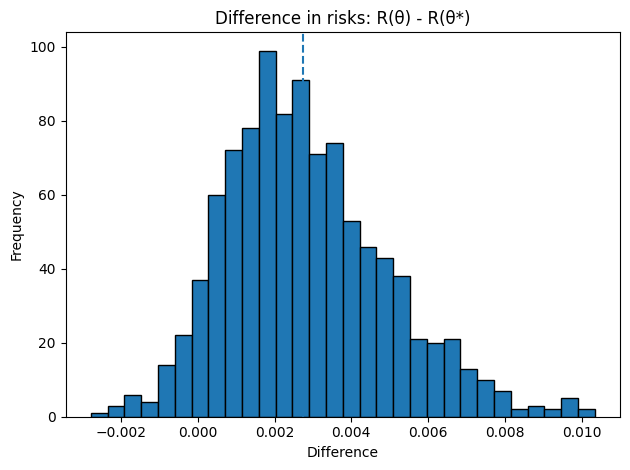

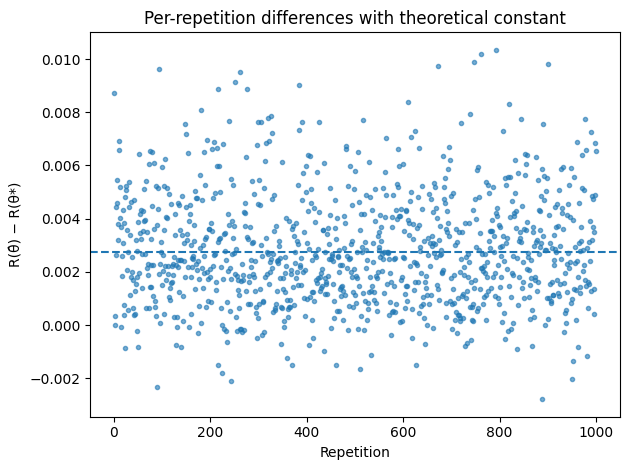

Mean difference: 0.002818
Theoretical constant: 0.002750
95% CI for mean difference: [0.002688, 0.002949]


In [24]:
reps = 1000
R_theta_hats = np.zeros(reps)
R_theta_stars = np.zeros(reps)

for i in range(reps):
    # Simulate the data
    Y, Z, epsilon, theta_star = simulate_linear_regression(n, p, sigma)

    # Solve for the theta hat
    theta_hat = np.linalg.solve(Z.T @ Z, Z.T @ Y)

    # Simulate test data
    I_p = np.eye(p)
    X_test = np.random.multivariate_normal(mean=np.zeros(p), cov=I_p, size = n)
    Z_test = np.column_stack([np.ones(n), X_test])
    epsilon_test = np.random.normal(0, sigma, n)
    Y_test = Z_test @ theta_star + epsilon_test

    # Get the true risk from the simulated test data
    R_theta_hats[i] = np.mean((Y_test - Z_test @ theta_hat)**2)
    R_theta_stars[i] = np.mean((Y_test - Z_test @ theta_star)**2)
    

# Differences and theoretical constant
deltas = R_theta_hats - R_theta_stars
constant = sigma**2 * (p + 1) / n

# Plot 1: histogram with theoretical constant
plt.figure()
plt.hist(deltas, bins=30, edgecolor='black')
plt.axvline(constant, linestyle='--')
plt.title("Difference in risks: R(θ) - R(θ*)")
plt.xlabel("Difference")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Plot 2: per-repetition scatter with constant
plt.figure()
plt.plot(np.arange(1, reps + 1), deltas, linestyle='', marker='.', alpha=0.6)
plt.axhline(constant, linestyle='--')
plt.title("Per-repetition differences with theoretical constant")
plt.xlabel("Repetition")
plt.ylabel("R(θ̂) − R(θ*)")
plt.tight_layout()
plt.show()

# Quick summary numbers
mean_delta = deltas.mean()
std_delta = deltas.std(ddof=1)
se_mean = std_delta / np.sqrt(reps)
ci_low = mean_delta - 1.96 * se_mean
ci_high = mean_delta + 1.96 * se_mean
print(f"Mean difference: {mean_delta:.6f}")
print(f"Theoretical constant: {constant:.6f}")
print(f"95% CI for mean difference: [{ci_low:.6f}, {ci_high:.6f}]")


# 2. Question 2

**From now on we consider the following data generation process. Let $p=8$ and let $X_i$ be a Gaussian vector as before. For each $i=1,\dots,n$,**
$$
Y_i = X_{i1} + (X_{i2})_+ + \epsilon_i
$$
**where $\epsilon_i$ is a Gaussian noise $\mathcal{N}(0, \sigma^2 = 0.5)$ and $(x)_+ = x \mathbb{1}_{(0,+\infty)}(x)$. Generate an independent and identically distributed collection of $n = 3000$ random variables from this distribution. With the help of simple graphs show that $x_1$ and $x_2$ have a particular relationship with the ouput $y$ compared to the others.**

---

Below is the code that plots the $Y$ variable against all the $X$ as well as $(X_2)_+$. From the graph it is directly visible that the $X_1$ and $X_2$ variable have a higher correlation with the $Y$ variable. We do see that the correlation with $X_1$ is higher than for $X_2$, which is due to the reason that the $Y$ is not directly a function of $X_2$ but instead of $(X_2)_+$. For the other variables we see that the correlation is close to 0, and we see in the scatterplots that the data appears to be completely random. This shows that the $X_1$ and $X_2$ havea particular relationship with the $Y$ compared to the other variables.

In [25]:
n = 3000
p = 8
sigma2 = 0.5

# Simulate the X
I_p = np.eye(p)
X = np.random.multivariate_normal(mean=np.zeros(p), cov=I_p, size = n)
X2_plus = X[:, 1] * (X[:, 1] > 0)

# Simulate epsilon
epsilon = np.random.normal(0, np.sqrt(sigma2))

# Simulate the Y
Y = X[:, 0] + X2_plus + epsilon

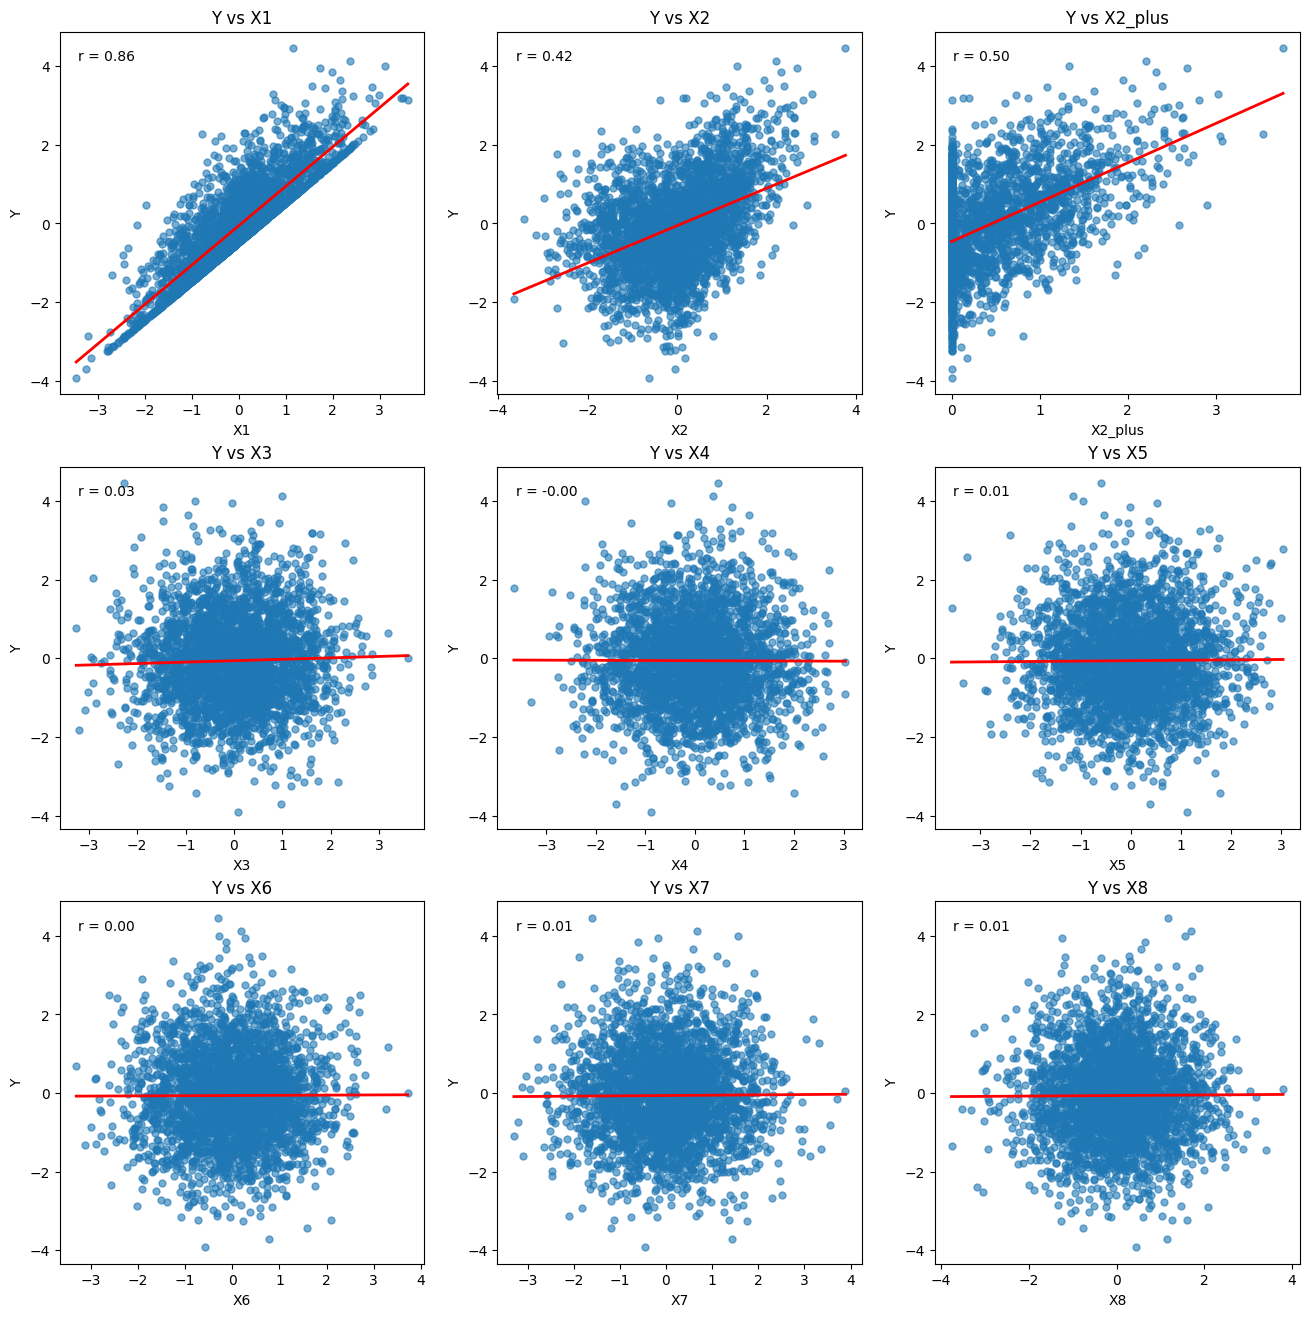

In [26]:
# Define the order of plotting
order = [
    ("X1",       X[:, 0]),
    ("X2",       X[:, 1]),
    ("X2_plus",  np.clip(X[:, 1], 0, None)),  # max(X2, 0)
    ("X3",       X[:, 2]),
    ("X4",       X[:, 3]),
    ("X5",       X[:, 4]),
    ("X6",       X[:, 5]),
    ("X7",       X[:, 6]),
    ("X8",       X[:, 7]),
]

# Initialize plot
fig, axes = plt.subplots(3, 3, figsize=(16, 16))

for ax, (name, x) in zip(axes.ravel(), order): 
    ax.scatter(x, Y, alpha=0.6, s=25)

    # Fit linear regression line in the plot
    model = LinearRegression().fit(x.reshape(-1, 1), Y)
    xx = np.linspace(x.min(), x.max(), 100)
    yy = model.predict(xx.reshape(-1, 1))
    ax.plot(xx, yy, color="red", lw=2)

    # Compute correlation coefficient
    r = np.corrcoef(x, Y)[0, 1]
    
    # Add title and labels
    ax.set_title(f"Y vs {name}")
    ax.set_xlabel(f"{name}")
    ax.set_ylabel("Y")
    
    # Add correlation text
    ax.text(0.05, 0.95, f"r = {r:.2f}", transform=ax.transAxes,
            fontsize=10, color="black", ha="left", va="top")



# 3. Question 3

**Define the linear regression estimator as**

$$
\hat{\beta}_n \in \arg\min_{\beta\in\mathbb{R}^{p+1}} = \{f(\theta) = n^{-1} \|Y - X\beta\|_2^2 \}.
$$

**Solve the above using standard implementation from sklearn. Print the empirical risk’s value for different values of $n \in \{100,500,1000,...,3000\}$. Give some comments about what is observed.**

---

I would like to note that I include a constant term in the model, even though the specification above is written in terms of the $X$ matrix rather than the $Z$ matrix. The reason is that, in the expression of the argmin, the parameter vector $\beta$ is defined to have dimension $p+1$. This implies that an intercept is intended to be part of the model, even if it is not explicitly represented in the notation.

Below is the plot of the empirical risk against the training size. We see that when training size increases, that the empirical risk increases. This might come as a surprise as you would expect the risk to go down when you have more observations. However, we use the in-sample empirical risk here, meaning that a small empirical risk here does not directly translate to a smaller risk outside of the sample. In other words, for small $n$, the model is overfitting allowing the risk to be small. When $n$ increases, the model can not overfit as much anymore which explains the increase in empirical risk. We do see that the empirical risk does seem to converge to a value below 0.90.



   n  empirical_risk
 100        0.072857
 500        0.088770
1000        0.094628
1500        0.092391
2000        0.093487
2500        0.092864
3000        0.093737


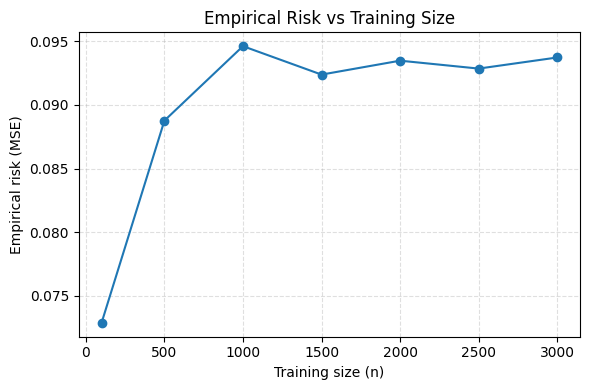

In [27]:
n_list = [100, 500, 1000, 1500, 2000, 2500, 3000]
empirical_risk = [0] * len(n_list)
for i, n in enumerate(n_list):
    X_small = X[0:n, :]
    Y_small = Y[0:n]
    model = LinearRegression(fit_intercept=True).fit(X_small, Y_small)
    Y_hat = model.predict(X_small)
    empirical_risk[i] = np.mean((Y_small - Y_hat) ** 2)

df = pd.DataFrame({"n": n_list, "empirical_risk": empirical_risk})

# Neatly formatted print
print(df.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(df["n"], df["empirical_risk"], marker="o")
ax.set_xlabel("Training size (n)")
ax.set_ylabel("Empirical risk (MSE)")
ax.set_title("Empirical Risk vs Training Size")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# 4. Question 4

**(first-order) No package should be used here except the basics like numpy. Apply the gradient
descent (GD) algorithm algorithm to the previous optimisation problem. The function to optimize
can be written as**

$$
f(\theta) = n^{-1} \sum_{i=1}^n f_i(\theta)
$$

**where $f_i(\theta) = (Y_i - X_i^\top \theta)^2$. Apply the stochastic gradient descent (SGD) algorithm to the above while sampling uniformly among the 3000 coordinates. In both GD and SGD, learning rate will be taken as $1/k$, $k$ being the iteration of the optimization algorithm. The number of evaluation of
the gradient of $f_i(\theta)$ shall be the same for each algorithm (i.e., take care that one step of GD takes many more evaluations). Provide pseudo-code to explain both algorithms. With the help of several experimental runs, and plotting the decrease of the function value f, visualize the randomness (and non-randomness) of SGD (of GD).**

---

Using the definition of the function $f$, we can compute the gradient as

$$
\nabla f(\theta) = n^{-1} \sum_{i=1}^n \nabla f_i(\theta)
$$

where $\nabla f_i(\theta) = -2 X_i (Y_i - X_i^\top \theta)$. For the full gradient, this would be equivalent to $\nabla f(\theta) = -\frac{2}{n} X^\top (Y - X\theta)$ where the $X$ and $Y$ are defined as in the course. Based on these definitions, we can now define the two algorithms.

---

### **1. Gradient Descent (GD)**

---

**Initialize:**

- $ \theta_0 \in \mathbb{R}^p $
- total iterations $K$

**Algorithm:**

For $k = 0, 1, \dots, K-1$:
1. Compute full gradient: $g_k = \nabla f(\theta_k) = -\frac{2}{n} X^\top (Y - X\theta)$  
2. Update parameters: $\theta_{k+1} = \theta_k - \frac{1}{k+1} g_k$  

**Return:** final parameter $ \theta_K $

---

### **2. Stochastic Gradient Descent (SGD)**

---

**Initialize:**
- $ \theta_0 \in \mathbb{R}^p $
- total epochs $K$

**Algorithm:**

For $k = 0, 1, \dots, K*n-1$:
    
1. Draw random index $i \in \{1, \dots, n\}$ uniformly
2. Compute stochastic gradient: $g_k = \nabla f_{i}(\theta_k) = -2 X_{i} (Y_{i} - X_{i}^\top \theta_k)$  
3. Update parameters: $\theta_{k+1} = \theta_k - \frac{1}{k+1} g_k$  

**Return:** final parameter $ \theta_{Kn} $

---

NOTE: the total number of evaluations of each gradient $\nabla f_i(\theta)$ is in this case equal to $nK$, just like for the GD algorithm. This ensures that both algorithms have the same number of gradient evaluations so we are able to compare them.

---

### **3. Results of experimental runs**

---

Note: the code for the gradient and the optimization procedure is written by me, the code for the plots comes from ChatGPT.

In the first plot below we see the losses of the SGD and GD method relative to the amount of evaluations of the gradient. We can see that for this particulair test run that the SGD method converges faster than the GD method. Well before 3000 evaluations of the gradients we see that SGD seem t have converged, while for GD that takes a bit longer. Also, we see that the line of the SGD method does not always go down, illustrating that using only one sample for each iteration might not always give the correct gradient to move to.

To illustrate the randomness of SGD, I plotted below the loss function for multiple runs with the same initialization in the second plot. We can see in the plot that all SGD methods converge, but especially in the beginning we se a difference in the losses. That shows that SGD is random, while GD will always result in the same line across multiple runs (if the intialization is the same).

To illustrate the difference between SGD and GD for different initial values I plotted the losses for SGD and GD when we use different intializations in the next plot. We observe that for both SGD and GD it takes longer to converge if we use a initial theta that is far from the true theta. However, SGD converges significantly faster than GD. This again shows that SGD is faster than GD, when we compare the efficiency with regards to number of gradient evaluations.


In [28]:
def gradient_full(X, Y, theta):
    n = X.shape[0]
    r = Y - X @ theta
    return -2 / n * X.T @ r

def gradient_stochastic(X_i, Y_i, theta):
    return -2 * X_i * (Y_i - X_i.T @ theta)

def f_full(X, Y, theta):
    n = X.shape[0]
    r = Y - X @ theta
    return (r @ r) / n

def gd(X, Y, K, theta0=None):
    """
    Full-batch Gradient Descent (GD)
    - Step size: gamma_k = 1 / (k+1)
    """
    n, p = X.shape
    theta = np.zeros(p) if theta0 is None else theta0.copy()
    losses = np.zeros(K)

    for k in range(K):
        g_k = gradient_full(X, Y, theta)
        lr = 1.0 / (k + 1)
        theta = theta - lr * g_k
        losses[k] = f_full(X, Y, theta)

    return theta, losses

def sgd(X, Y, K, theta0=None):
    """
    Stochastic Gradient Descent (single-sample updates)
    - Total updates: K * n
    - Step size: gamma_k = 1 / (k+1)
    """
    n, p = X.shape
    theta = np.zeros(p) if theta0 is None else theta0.copy()
    losses = np.zeros(K * n)
    idx = np.random.randint(0, n, K * n)

    for k in range(K * n):
        i = idx[k]
        Xi = X[i, :]
        Yi = Y[i]
        g_k = gradient_stochastic(Xi, Yi, theta)
        lr = 1.0 / (k + 1)
        theta = theta - lr * g_k
        losses[k] = f_full(X, Y, theta)

    return theta, losses


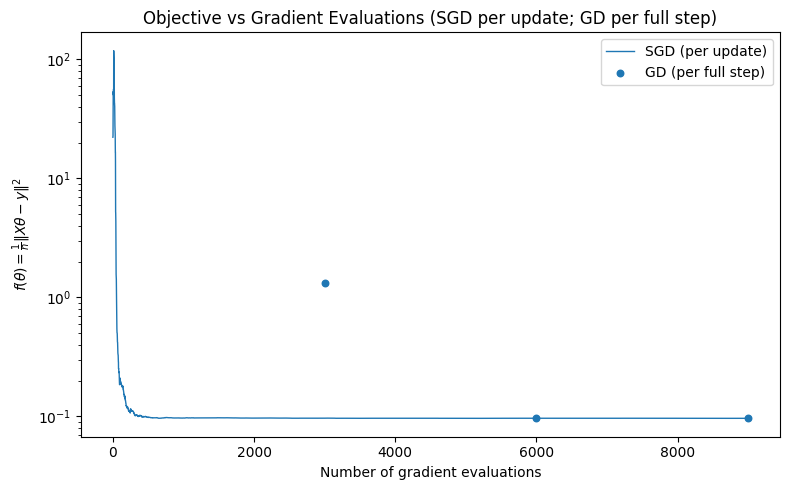

In [29]:
# Run experiments
K = 3
theta0 = np.zeros(X.shape[1])

theta_gd, loss_gd = gd(X, Y, K, theta0)
theta_sgd, loss_sgd = sgd(X, Y, K, theta0)

reps_gd = np.arange(n, K * n + 1, n)
reps_sgd = np.arange(1, K * n + 1)

# Plot: f vs. number of gradient evaluations
plt.figure(figsize=(8, 5))
plt.plot(reps_sgd, loss_sgd, linewidth=1, label="SGD (per update)")
plt.scatter(reps_gd, loss_gd, s=22, label="GD (per full step)", zorder=3)

plt.xlabel("Number of gradient evaluations")
plt.ylabel(r"$f(\theta) = \frac{1}{n}\|X\theta - y\|^2$")
plt.title("Objective vs Gradient Evaluations (SGD per update; GD per full step)")
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()

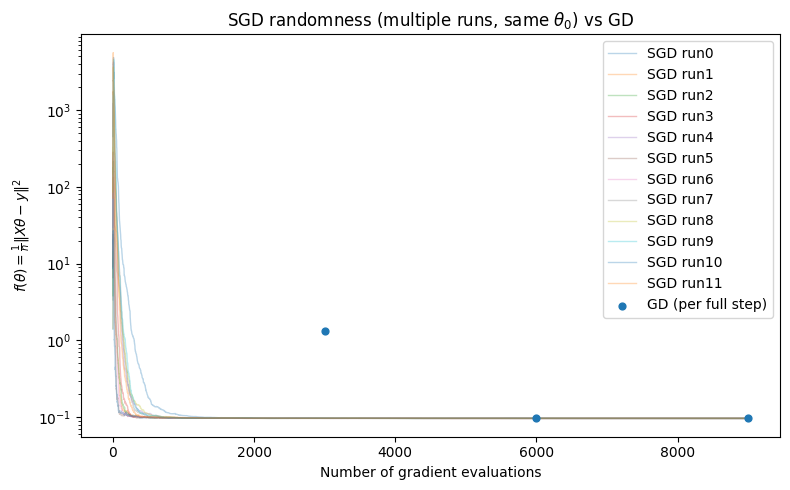

In [30]:
# SGD randomness with same theta0
K = 3
n_runs = 12                  # number of independent SGD runs
theta0 = np.zeros(X.shape[1])

# One deterministic GD run for reference
theta_gd, loss_gd = gd(X, Y, K, theta0)
reps_gd = n * np.arange(1, K + 1)

# Multiple SGD runs (different randomness, same theta0)
loss_sgd_runs = np.zeros((n_runs, K * n))
for r in range(n_runs):
    # fresh randomness per run
    _ = np.random.seed(10_000 + r)
    _, loss_sgd_r = sgd(X, Y, K, theta0)
    loss_sgd_runs[r, :] = loss_sgd_r

# Plot: all SGD trajectories 
plt.figure(figsize=(8, 5))
evals_sgd = np.arange(1, K * n + 1)

# individual SGD runs
for r in range(n_runs):
    plt.plot(evals_sgd, loss_sgd_runs[r, :], lw=1, alpha=0.30, label=f"SGD run{r}")

# GD reference
plt.scatter(reps_gd, loss_gd, s=24, zorder=3, label="GD (per full step)")

plt.xlabel("Number of gradient evaluations")
plt.ylabel(r"$f(\theta) = \frac{1}{n}\|X\theta - y\|^2$")
plt.title("SGD randomness (multiple runs, same $\\theta_0$) vs GD")
plt.yscale("log"); plt.legend(); plt.tight_layout(); plt.show()



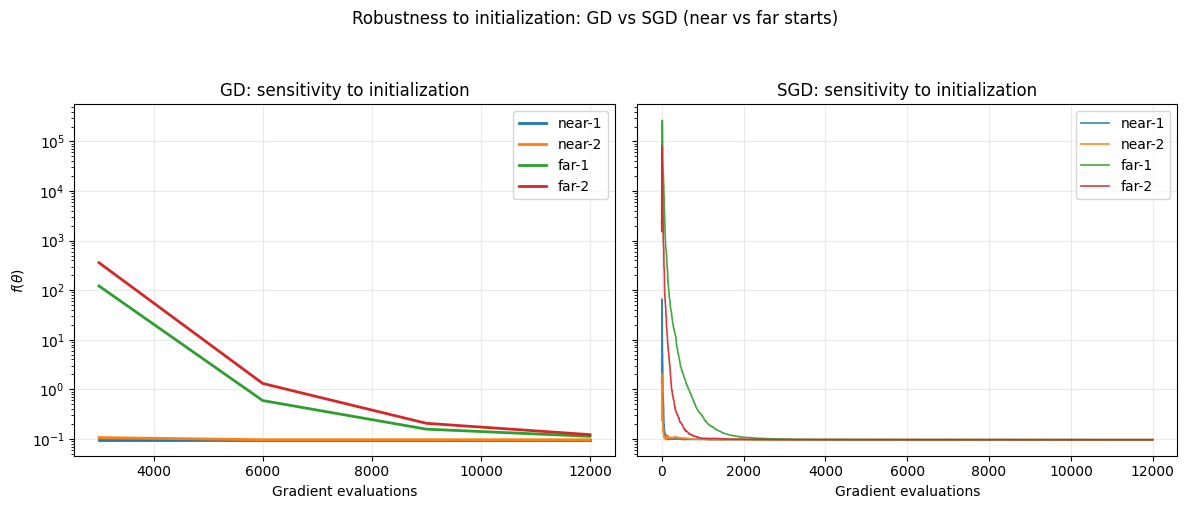

In [31]:
# Robustness to initialization
p = X.shape[1]

# If you know the ground truth theta_star from data generation, set it here:
# theta_star = <your true parameter>
# Otherwise: use OLS as a proxy for a "good/near" start:
theta_star, *_ = np.linalg.lstsq(X, Y, rcond=None)

rng = np.random.default_rng(123)

# Near starts
theta_near1 = theta_star.copy()
theta_near2 = theta_star + 0.05 * rng.normal(size=p)   # small perturbation

# Far starts
theta_far1  = 5.0 * rng.normal(size=p)                 # large random
theta_far2  = -5.0 * rng.normal(size=p)                # another large random (opposite-ish)

inits = {
    "near-1": theta_near1,
    "near-2": theta_near2,
    "far-1":  theta_far1,
    "far-2":  theta_far2,
}

K = 4  # epochs

# Run GD & SGD for each init
results = {}
for name, th0 in inits.items():
    theta_gd_i,  loss_gd_i  = gd(X, Y, K, th0)
    theta_sgd_i, loss_sgd_i = sgd(X, Y, K, th0)
    results[name] = {
        "gd":  (n * np.arange(1, K + 1), loss_gd_i),
        "sgd": (np.arange(1, K * n + 1), loss_sgd_i),
    }

# Two subplots (GD vs SGD)
import itertools
colors = plt.cm.tab10.colors
palette = dict(zip(inits.keys(), itertools.islice(colors, len(inits))))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)

# Left: GD
ax = axes[0]
for name, (x, y) in {k: v["gd"] for k, v in results.items()}.items():
    ax.plot(x, y, label=name, lw=2, color=palette[name])
ax.set_title("GD: sensitivity to initialization")
ax.set_xlabel("Gradient evaluations"); ax.set_ylabel(r"$f(\theta)$")
ax.set_yscale("log"); ax.legend(); ax.grid(alpha=0.25)

# Right: SGD 
ax = axes[1]
for name, (x, y) in {k: v["sgd"] for k, v in results.items()}.items():
    ax.plot(x, y, label=name, lw=1.2, alpha=0.9, color=palette[name])
ax.set_title("SGD: sensitivity to initialization")
ax.set_xlabel("Gradient evaluations"); ax.set_yscale("log"); ax.legend(); ax.grid(alpha=0.25)

fig.suptitle("Robustness to initialization: GD vs SGD (near vs far starts)", y=1.05, fontsize=12)
plt.tight_layout(); plt.show()


# 5. Question 5
**(zero-order) Now is supposed that we cannot evaluate the gradient. Explain that, when $h$ is small,**

$$
h^{-1}U\{f(\theta + hU) - f(\theta - hU)\} \approx U U^\top \nabla f(\theta)
$$

**Propose a way to generate $U$ in the perspective gradient descent algorithms. Write a pseudo-code to describe an algorithm relying on the above estimate of gradient. The first proposed algorithm, called ZGD, should use full function evaluation $f(\theta) = n^{-1} \sum_{i=1}^n f_i(\theta)$ at each iteration (i.e., when
estimating the gradient), but a stochastic version, called ZSGD, should also be provided. Compare the two algorithms to the standard GD and SGD from before**

---

#### **1. Why can we express the gradient in this form?**

We want to express the gradient $\nabla f(\theta)$ using only function values. Consider the Taylor expansion of $f$ around $\theta$ in the direction $U$:

$$
f(\theta + hU) = f(\theta) + h\,U^\top \nabla f(\theta) + \frac{h^2}{2} U^\top H(\theta) U + O(h^3),
$$

$$
f(\theta - hU) = f(\theta) - h\,U^\top \nabla f(\theta) + \frac{h^2}{2} U^\top H(\theta) U + O(h^3).
$$

where $H(\theta)$ is the Hessian of the function $f$. Subtracting the two expressions gives

$$
f(\theta + hU) - f(\theta - hU) = 2h\,U^\top \nabla f(\theta) + O(h^3).
$$

Multiplying by $U$ and dividing by $h$, we obtain

$$
h^{-1}U\big(f(\theta + hU) - f(\theta - hU)\big)
\approx 2\,UU^\top \nabla f(\theta).
$$

The above expression shows the result we wanted to prove, apart from the factor 2. However, with gradient descent algorithms we are often only interested in the direction of the gradient, as we can control the magnitude with the step size of the algorithm. Using that we obtain our final expression for the gradient as

$$
h^{-1}U\{f(\theta + hU) - f(\theta - hU)\} \approx UU^\top \nabla f(\theta).
$$

This means that by evaluating $f$ at two nearby points along a random direction $U$, we obtain an estimator proportional to the true gradient.

---

#### **2. What is $U$?**

The vector $U \in \mathbb{R}^p$ is a **random direction** which allows us to estimate the gradient by analysing how $f$ changes. Since we want to estimate the gradient, we should have that the above estimator is (approximately) proportional to the gradient. This means that we should have that

$$
\mathbb{E}[UU^\top] = I_p.
$$

Such that we obtain that

$$
\mathbb{E}\left[h^{-1}U\{f(\theta + hU) - f(\theta - hU)\}\right] \approx \mathbb{E}\left[UU^\top \nabla f(\theta)\right] = \mathbb{E}\left[UU^\top\right] \mathbb{E}\left[\nabla f(\theta)\right] = \mathbb{E}\left[\nabla f(\theta)\right].
$$

Additionally, it would be beneficial to have $\mathbb{E}\left[U\right] = 0$ such that we explore the space equally and the updates do not drift away even when the true gradient is 0. The easiest way to obtain such a U is to simulate $U \sim \mathcal{N}(0, I_p)$ (standard Gaussian).

---

#### **3. How can we use this for Gradient Descent and Stochastic Gradient Descent?**

We can use the estimator above as a replacement for the true gradient in descent algorithms.  

##### **Zeroth-Order Gradient Descent (ZGD)**
- Uses the **full function** $f(\theta)$ for each iteration.  
- Each iteration requires **two function evaluations**: at $\theta_k + hU_k$ and $\theta_k - hU_k$.  
- The update is deterministic apart from the randomness in $U_k$.

**Initialize:**

- $ \theta_0 \in \mathbb{R}^p $
- total iterations $K$
- step size $\gamma_k$ for each iteration

**Algorithm:**

For $k = 0, 1, \dots, K-1$:
1. Estimate full gradient: $\widehat g_k = \frac{1}{h}\,U_k \big(f(\theta_k + hU_k) - f(\theta_k - hU_k)\big)$  
2. Update parameters: $\theta_{k+1} = \theta_k - \gamma_k \widehat g_k$  

**Return:** final parameter $ \theta_K $

##### **Zeroth-Order Stochastic Gradient Descent (ZSGD)**
- Uses **one data point** or **one component function** $f_i(\theta)$ at each iteration.  
- The update is stochastic in both the randomness in $U_k$ and the Monte Carlo draw for the index $i$.

**Initialize:**
- $ \theta_0 \in \mathbb{R}^p $
- total epochs $K$
- step size $\gamma_k$ for each iteration

**Algorithm:**

For $k = 0, 1, \dots, K*n-1$:
    
1. Draw random index $i \in \{1, \dots, n\}$ uniformly
2. Estimate stochastic gradient: $\widehat g_k = \frac{1}{h}\,U_k \big(f_i(\theta_k + hU_k) - f_i(\theta_k - hU_k)\big)$,
3. Update parameters: $\theta_{k+1} = \theta_k - \gamma_k \widehat g_k$  

**Return:** final parameter $ \theta_{Kn} $

---

#### **4. Comparison of ZGD and ZSGD with GD and SGD**

For this assignment, I saw that using the learning rate $1/k$ as we had before resulted in non-stable results. Therefore, I opted for a learning rate of $0.1 / k^{0.5}$ to let the learning rate in the beginning be smaller compared to in the end of the algorithm. This prevents the algorithm from taking a wrong step in the beginning and not being able to recover from it. 

In the plots below we see that both ZGD and ZSGD seem to converge to a stable point in terms of the loss. However, when comparing it against GD and SGD (plotted again here for convenience) we observe again that it takes more evaluations of the gradient to get this convergence. This shows that, while it will converge in the end, it can take much longer for ZGD and ZSGD as they have extra introduced randomness. We can also see this from looking at the individual lines. We see that the variance of the loss is much higher for the zero-order methods than for the normal gradient methods. Again, we see that the stochastic version converges faster than the non-stochastic one if we purely look at the amount of gradients evaluated.

---

In [32]:
def f_full(X, Y, theta):
    n = X.shape[0]
    r = Y - X @ theta
    return (r @ r) / n

def f_i(X_i, Y_i, theta):
    return (Y_i - X_i @ theta) ** 2


def zgd(X, Y, K, h=1e-3, theta0=None, X_test=None, Y_test=None):
    """
    Zeroth-Order Gradient Descent (ZGD)
    - Uses the full function f(theta)
    - Step size: gamma_k = 1 / (k+1)
    - Gradient approximation: g_k = (1/h) U [f(theta+hU) - f(theta-hU)]
    """
    n, p = X.shape
    theta = np.zeros(p) if theta0 is None else theta0.copy()
    losses = np.zeros(K)
    losses_test = np.zeros(K)

    U = np.random.normal(size=(p, K))
    for k in range(K):
        U_k = U[:, k]
        f_plus  = f_full(X, Y, theta + h * U_k)
        f_minus = f_full(X, Y, theta - h * U_k)
        g_hat = (1.0 / h) * U_k * (f_plus - f_minus)
        lr = 0.1 / np.sqrt(k + 1)
        theta = theta - lr * g_hat
        losses[k] = f_full(X, Y, theta)

        if X_test is not None and Y_test is not None:
            losses_test[k] = f_full(X_test, Y_test, theta)

    return theta, losses, losses_test


def zsgd(X, Y, K, h=1e-3, theta0=None, X_test=None, Y_test=None):
    """
    Zeroth-Order Stochastic Gradient Descent (ZSGD)
    - Uses one sample f_i(theta) per update
    - Total updates: K * n
    - Step size: gamma_k = 1 / (k+1)
    - Gradient approximation: g_k = (1/h) U [f_i(theta+hU) - f_i(theta-hU)]
    """
    n, p = X.shape
    theta = np.zeros(p) if theta0 is None else theta0.copy()
    losses = np.zeros(K * n)
    losses_test = np.zeros(K * n)
    
    idx = np.random.randint(0, n, K * n)
    U = np.random.normal(size=(p, K * n))
    for k in range(K * n):
        i = idx[k]
        Xi = X[i, :]
        Yi = Y[i]
        U_k = U[:, k]
        f_plus  = f_i(Xi, Yi, theta + h * U_k)
        f_minus = f_i(Xi, Yi, theta - h * U_k)
        g_hat = (1.0 / h) * U_k * (f_plus - f_minus)
        lr = 0.1 / np.sqrt(k + 1)
        theta = theta - lr * g_hat
        losses[k] = f_full(X, Y, theta)

        if X_test is not None and Y_test is not None:
            losses_test[k] = f_full(X_test, Y_test, theta)

    return theta, losses, losses_test



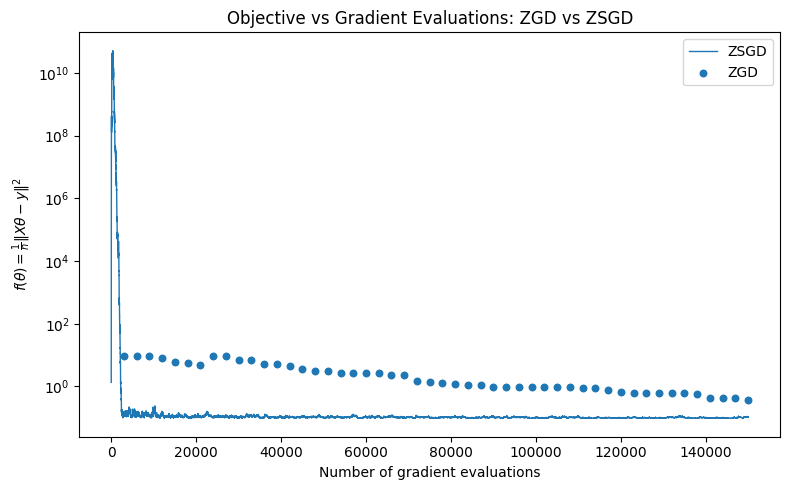

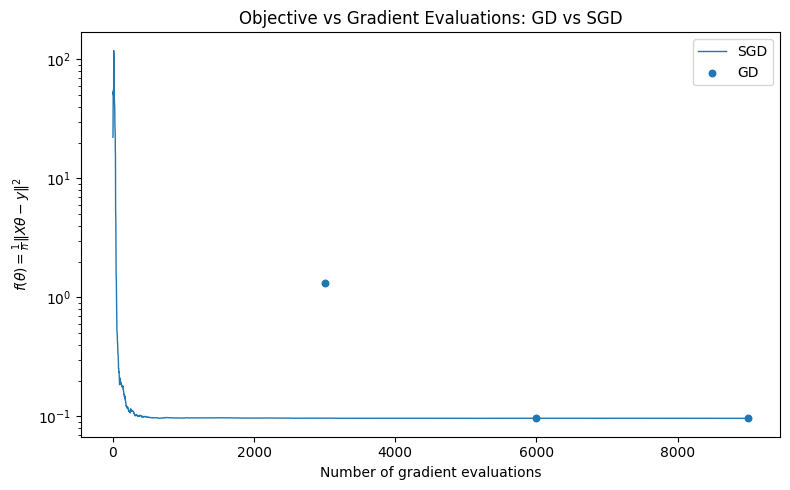

In [33]:
# Run experiments
K = 50
h = 1e-3
theta0 = np.zeros(X.shape[1])

theta_zgd, loss_zgd, _ = zgd(X, Y, K, h, theta0)
theta_zsgd, loss_zsgd, _ = zsgd(X, Y, K, h, theta0)

reps_zgd = np.arange(n, K * n + 1, n)
reps_zsgd = np.arange(1, K * n + 1)

# Plot: ZGD and ZSGD
plt.figure(figsize=(8, 5))
plt.plot(reps_zsgd, loss_zsgd, linewidth=1, label="ZSGD")
plt.scatter(reps_zgd, loss_zgd, s=22, label="ZGD", zorder=3)

plt.xlabel("Number of gradient evaluations")
plt.ylabel(r"$f(\theta) = \frac{1}{n}\|X\theta - y\|^2$")
plt.title("Objective vs Gradient Evaluations: ZGD vs ZSGD")
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()


# Plot: GD and SGD
plt.figure(figsize=(8, 5))
plt.plot(reps_sgd, loss_sgd, linewidth=1, label="SGD")
plt.scatter(reps_gd, loss_gd, s=22, label="GD", zorder=3)

plt.xlabel("Number of gradient evaluations")
plt.ylabel(r"$f(\theta) = \frac{1}{n}\|X\theta - y\|^2$")
plt.title("Objective vs Gradient Evaluations: GD vs SGD")
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()

# 6. Question 6
**Now consider a more flexible model defined as**

$$
f_{\beta,\gamma}(x) = x^\top \beta + (x^\top \gamma)_+.
$$

**Train the model with ZSGD and ZGD and compare them in terms of the value function $f$ while using the same number of evaluation of $f$ for both methods. Evaluate/Estimate the risk using $n = 1000$ additional generations from the previous data generation process. Compare the two above approaches: (a) ZSGD with the complex model and (b) ZSGD with the linear model (with fixed number of evaluation of $f_i(\beta)$).**

---

Using the model defined as above, I will define the empirical risk we want to minimize as

$$
f(\beta, \gamma) = n^{-1} \sum_{i=1}^n (Y_i - f_{\beta,\gamma}(X_i))^2
$$.

Note that in this case we would have $\theta = (\beta, \gamma)$ in our ZSGD and ZGD optimization.

The plot below compares the evolution of the empirical risk for the zeroth-order gradient descent and zeroth-order stochastic gradient descent algorithms, applied to both the complex and  simpler linear model. The horizontal axis shows the number of gradient evaluations, so both methods are compared under the same computational budget. The difference between the two algorithms is clearly visible: the gradient descent curves are smooth and deterministic, while the stochastic gradient descent curves fluctuate because of the randomness introduced by sampling individual observations.

The linear model converges much faster and in a much more stable way than the complex model. Its objective value decreases rapidly and remains close to its minimum after only a few updates, which is expected since the linear model is convex and smooth. The complex model, on the other hand, shows a large initial spike and then a slow and unstable decrease. This behavior reflects the difficulty of optimizing a model that is nonlinear and non-convex, even though it might be closer to the true data generating process.

Overall, the plot illustrates both the randomness of the stochastic approach and the stability of the deterministic one. While stochastic gradient descent can reach similar regions of the parameter space as gradient descent, its path is more irregular and sensitive to randomness. The linear model demonstrates faster and more robust convergence, whereas the complex model provides greater flexibility but at the cost of slower and less stable optimization.

In [ ]:
def split_theta(theta, p):
    beta  = theta[:p]
    gamma = theta[p:]
    return beta, gamma

def predict_complex(X, theta):
    n, p = X.shape
    beta, gamma = split_theta(theta, p)
    return X @ beta + np.maximum(0.0, X @ gamma)

def f_i_complex(Xi, Yi, theta):
    p = Xi.shape[0]
    yhat = Xi @ theta[:p] + max(0.0, Xi @ theta[p:])
    err = Yi - yhat
    return err * err

def f_full_complex(X, Y, theta):
    n, p = X.shape
    r = Y - predict_complex(X, theta)
    return (r @ r) / n

def zgd_complex(X, Y, K, h=1e-3, theta0=None, X_test=None, Y_test=None):
    """
    Zeroth-order GD on the complex model (beta,gamma)
    """
    n, p = X.shape
    d = 2 * p
    theta = np.zeros(d) if theta0 is None else theta0.copy()
    losses = np.zeros(K)
    losses_test = np.zeros(K)

    U = np.random.normal(size = (d, K))
    for k in range(K):
        U_k = U[:, k]
        f_plus  = f_full_complex(X, Y, theta + h * U_k)
        f_minus = f_full_complex(X, Y, theta - h * U_k)
        ghat = (1.0 / h) * U_k * (f_plus - f_minus)
        lr = 0.1 / np.sqrt(k + 1)
        theta = theta - lr * ghat
        losses[k] = f_full_complex(X, Y, theta)
        if X_test is not None and Y_test is not None:
            losses_test[k] = f_full_complex(X_test, Y_test, theta)


    return theta, losses, losses_test

def zsgd_complex(X, Y, K, h=1e-3, theta0=None, X_test=None, Y_test=None):
    """
    ZSGD on the complex model (beta,gamma)
    - total updates: K*n (to match GD cost in fi-evals)
    """
    n, p = X.shape
    d = 2 * p
    theta = np.zeros(d) if theta0 is None else theta0.copy()
    losses = np.zeros(K * n)
    losses_test = np.zeros(K * n)

    U = np.random.normal(size = (d, K * n))
    idx = np.random.randint(0, n, size=K * n)
    for k in range(K * n):
        i = idx[k]
        Xi, Yi = X[i, :], Y[i]
        U_k = U[:, k]
        f_plus  = f_i_complex(Xi, Yi, theta + h * U_k)
        f_minus = f_i_complex(Xi, Yi, theta - h * U_k)
        ghat = (1.0 / h) * U_k * (f_plus - f_minus)
        lr = 0.1 / np.sqrt(k + 1)
        theta = theta - lr * ghat
        losses[k] = f_full_complex(X, Y, theta)
        if X_test is not None and Y_test is not None:
            losses_test[k] = f_full_complex(X_test, Y_test, theta)


    return theta, losses, losses_test

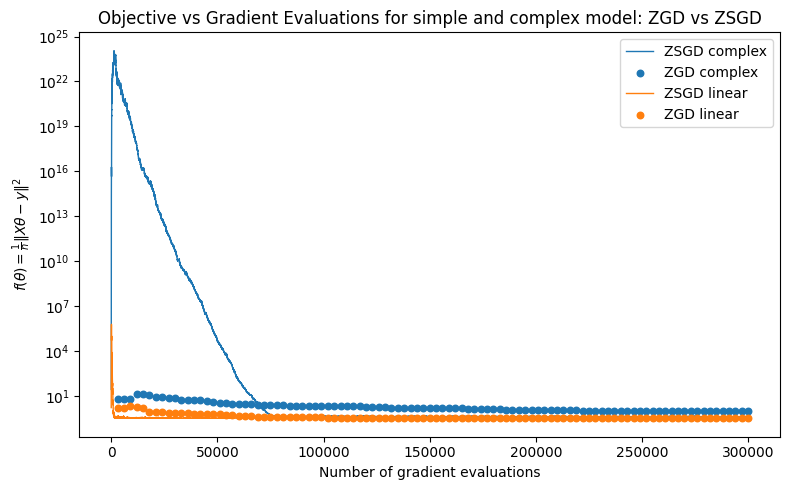

In [35]:
# Simulate the X_test with 1000 observations
n_test = 1000
I_p = np.eye(p)
X_test = np.random.multivariate_normal(mean=np.zeros(p), cov=I_p, size = n_test)
X2_plus_test = X_test[:, 1] * (X_test[:, 1] > 0)

# Simulate epsilon
epsilon_test = np.random.normal(0, np.sqrt(sigma2))

# Simulate the Y
Y_test = X_test[:, 0] + X2_plus_test + epsilon_test

# Run experiments
K = 100
h = 1e-3
theta0_complex = np.zeros(2 * X.shape[1])

# Run complex model
theta_zgd_complex, loss_zgd_complex, loss_zgd_complex_test = zgd_complex(X, Y, K, h, theta0_complex, X_test, Y_test)
theta_zsgd_complex, loss_zsgd_complex, loss_zsgd_complex_test = zsgd_complex(X, Y, K, h, theta0_complex, X_test, Y_test)

reps_zgd_complex = np.arange(n, K * n + 1, n)
reps_zsgd_complex = np.arange(1, K * n + 1)

# Run simple model 
theta_zgd, loss_zgd, loss_zgd_test = zgd(X, Y, K, h, theta0, X_test, Y_test)
theta_zsgd, loss_zsgd, loss_zsgd_test = zsgd(X, Y, K, h, theta0, X_test, Y_test)

reps_zgd = np.arange(n, K * n + 1, n)
reps_zsgd = np.arange(1, K * n + 1)

# Plot: f vs. number of gradient evaluations
plt.figure(figsize=(8, 5))
plt.plot(reps_zsgd_complex, loss_zsgd_complex_test, linewidth=1, label="ZSGD complex")
plt.scatter(reps_zgd_complex, loss_zgd_complex_test, s=22, label="ZGD complex", zorder=3)

plt.plot(reps_zsgd, loss_zsgd_test, linewidth=1, label="ZSGD linear")
plt.scatter(reps_zgd, loss_zgd_test, s=22, label="ZGD linear", zorder=3)

plt.xlabel("Number of gradient evaluations")
plt.ylabel(r"$f(\theta) = \frac{1}{n}\|X\theta - y\|^2$")
plt.title("Objective vs Gradient Evaluations for simple and complex model: ZGD vs ZSGD")
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()

# 7. Question 7

**(bonus question) Consider the classification data from https://archive.ics.uci.edu/dataset/159/magic+gamma+telescope. Train one base line model e.g., logistic regression, and compare it to your own model which might be anything (e.g., you can still do logistic regression or neural network classification) but training should be based on zero-th stochastic gradient descent (as before). Explain and give the details about the procedure you propose.**

I choose to compare the default implementation of sklearn logistic regression to one where I solve it with zero stochastic gradient descent. The code to estimate logistic regression with zero stochastic gradient descent has been written by ChatGPT. It uses a batch size for the stochastic gradient descent of 256. We can see that sklearn method does better than the ZSGD, probably due to convergence issues we saw earlier with ZSGD. However, our method still outperforms pure randomness.

In [36]:
# Load the data
cols = ["fLength","fWidth","fSize","fConc","fConc1", "fAsym","fM3Long","fM3Trans","fAlpha","fDist","class"]
df = pd.read_csv("magic04.data", names=cols)
df["class"] = (df["class"] == "g").astype(int)

X = df.drop(columns=["class"])
Y = df["class"]

print(X)
print(Y)

        fLength    fWidth   fSize   fConc  fConc1     fAsym   fM3Long  \
0       28.7967   16.0021  2.6449  0.3918  0.1982   27.7004   22.0110   
1       31.6036   11.7235  2.5185  0.5303  0.3773   26.2722   23.8238   
2      162.0520  136.0310  4.0612  0.0374  0.0187  116.7410  -64.8580   
3       23.8172    9.5728  2.3385  0.6147  0.3922   27.2107   -6.4633   
4       75.1362   30.9205  3.1611  0.3168  0.1832   -5.5277   28.5525   
...         ...       ...     ...     ...     ...       ...       ...   
19015   21.3846   10.9170  2.6161  0.5857  0.3934   15.2618   11.5245   
19016   28.9452    6.7020  2.2672  0.5351  0.2784   37.0816   13.1853   
19017   75.4455   47.5305  3.4483  0.1417  0.0549   -9.3561   41.0562   
19018  120.5135   76.9018  3.9939  0.0944  0.0683    5.8043  -93.5224   
19019  187.1814   53.0014  3.2093  0.2876  0.1539 -167.3125 -168.4558   

       fM3Trans   fAlpha     fDist  
0       -8.2027  40.0920   81.8828  
1       -9.9574   6.3609  205.2610  
2      -45.2

Accuracy: 0.788 | ROC-AUC: 0.839

              precision    recall  f1-score   support

           0      0.757     0.586     0.660      1672
           1      0.800     0.898     0.846      3083

    accuracy                          0.788      4755
   macro avg      0.778     0.742     0.753      4755
weighted avg      0.785     0.788     0.781      4755



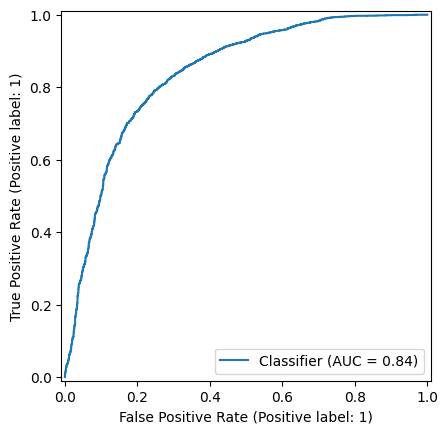

In [37]:
# Train the baseline model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, RocCurveDisplay, classification_report

# Train/valid split (stratified)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.25, random_state=seed, stratify=Y)

model = LogisticRegression(random_state=seed, max_iter = 5000)
model.fit(X_train, y_train)

baseline_pred = model.predict(X_test)
baseline_proba = model.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, baseline_pred)
auc = roc_auc_score(y_test, baseline_proba)

print(f"Accuracy: {acc:.3f} | ROC-AUC: {auc:.3f}\n")
print(classification_report(y_test, baseline_pred, digits=3))

# (Optional) ROC curve
_ = RocCurveDisplay.from_predictions(y_test, baseline_proba)

[t=   1] minibatch loss=89.4341 | val AUC=0.562


/tmp/ipykernel_51096/3404199004.py:26: RuntimeWarning: overflow encountered in exp
  loss = np.where(yz > 0, np.log1p(np.exp(-yz)), (-yz) + np.log1p(np.exp(yz)))
/tmp/ipykernel_51096/3404199004.py:26: RuntimeWarning: overflow encountered in exp
  loss = np.where(yz > 0, np.log1p(np.exp(-yz)), (-yz) + np.log1p(np.exp(yz)))
/tmp/ipykernel_51096/3404199004.py:26: RuntimeWarning: overflow encountered in exp
  loss = np.where(yz > 0, np.log1p(np.exp(-yz)), (-yz) + np.log1p(np.exp(yz)))


[t= 300] minibatch loss=113.5354 | val AUC=0.676
[t= 600] minibatch loss=54.5241 | val AUC=0.669
[t= 900] minibatch loss=38.7255 | val AUC=0.669
[t=1200] minibatch loss=34.1802 | val AUC=0.711


/tmp/ipykernel_51096/3404199004.py:26: RuntimeWarning: overflow encountered in exp
  loss = np.where(yz > 0, np.log1p(np.exp(-yz)), (-yz) + np.log1p(np.exp(yz)))
/tmp/ipykernel_51096/3404199004.py:26: RuntimeWarning: overflow encountered in exp
  loss = np.where(yz > 0, np.log1p(np.exp(-yz)), (-yz) + np.log1p(np.exp(yz)))
/tmp/ipykernel_51096/3404199004.py:26: RuntimeWarning: overflow encountered in exp
  loss = np.where(yz > 0, np.log1p(np.exp(-yz)), (-yz) + np.log1p(np.exp(yz)))


[t=1500] minibatch loss=39.2389 | val AUC=0.509
[t=1800] minibatch loss=18.1601 | val AUC=0.674
[t=2100] minibatch loss=15.8378 | val AUC=0.755


/tmp/ipykernel_51096/3404199004.py:26: RuntimeWarning: overflow encountered in exp
  loss = np.where(yz > 0, np.log1p(np.exp(-yz)), (-yz) + np.log1p(np.exp(yz)))
/tmp/ipykernel_51096/3404199004.py:26: RuntimeWarning: overflow encountered in exp
  loss = np.where(yz > 0, np.log1p(np.exp(-yz)), (-yz) + np.log1p(np.exp(yz)))
/tmp/ipykernel_51096/3404199004.py:26: RuntimeWarning: overflow encountered in exp
  loss = np.where(yz > 0, np.log1p(np.exp(-yz)), (-yz) + np.log1p(np.exp(yz)))


[t=2400] minibatch loss=10.8841 | val AUC=0.732
[t=2700] minibatch loss=17.5084 | val AUC=0.623
[t=3000] minibatch loss=12.2976 | val AUC=0.677

ZSGD Logistic — Accuracy: 0.655 | ROC-AUC: 0.677

              precision    recall  f1-score   support

           0      0.509     0.527     0.518      1672
           1      0.739     0.725     0.731      3083

    accuracy                          0.655      4755
   macro avg      0.624     0.626     0.625      4755
weighted avg      0.658     0.655     0.656      4755



/tmp/ipykernel_51096/3404199004.py:26: RuntimeWarning: overflow encountered in exp
  loss = np.where(yz > 0, np.log1p(np.exp(-yz)), (-yz) + np.log1p(np.exp(yz)))
/tmp/ipykernel_51096/3404199004.py:26: RuntimeWarning: overflow encountered in exp
  loss = np.where(yz > 0, np.log1p(np.exp(-yz)), (-yz) + np.log1p(np.exp(yz)))


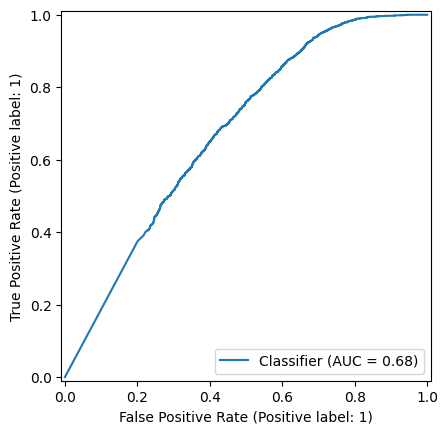

In [38]:
# --- Helpers: add bias term, sigmoid, logistic loss on a batch ---
def add_bias(X):
    return np.c_[np.ones((X.shape[0], 1)), X]

def sigmoid(z):
    # stable sigmoid
    pos = z >= 0
    neg = ~pos
    out = np.empty_like(z, dtype=float)
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    ez = np.exp(z[neg])
    out[neg] = ez / (1.0 + ez)
    return out

def batch_logistic_loss(theta, Xb, y01, l2=0.0):
    """
    Xb: (m, p+1) with bias column
    y01: in {0,1}
    """
    # convert labels to {-1, +1} for the logistic formula
    ypm = 2*y01 - 1
    z = Xb @ theta
    # logistic loss: log(1 + exp(-y z))
    # use stable computation
    yz = ypm * z
    loss = np.where(yz > 0, np.log1p(np.exp(-yz)), (-yz) + np.log1p(np.exp(yz)))
    return loss.mean() + 0.5*l2*np.dot(theta[1:], theta[1:])  # don't penalize bias

# --- Zero-order SGD for logistic regression (two-point estimate) ---
def zsgd_logreg(
    X_train_std, y_train, X_val_std=None, y_val=None,
    steps=3000, batch_size=256, lr=0.1, h=1e-3, l2=1e-4,
    eval_every=250, seed=42, lr_decay=None
):
    """
    Trains theta via zero-order SGD (two-point). Returns theta and history.
    lr_decay: function taking step index t -> learning rate multiplier (optional)
    """
    rng = np.random.default_rng(seed)
    Xb = add_bias(X_train_std)
    n, p1 = Xb.shape
    theta = np.zeros(p1)  # includes bias
    history = {"step": [], "train_loss": [], "val_auc": []}

    # precompute biased versions for validation
    Xb_val = add_bias(X_val_std) if X_val_std is not None else None

    for t in range(1, steps+1):
        # mini-batch
        idx = rng.integers(0, n, size=batch_size)
        Xmb = Xb[idx]
        ymb = y_train.iloc[idx].to_numpy()
        
        # random direction ~ N(0, I)
        u = rng.normal(size=p1)

        # two-point function evaluations
        f_plus  = batch_logistic_loss(theta + h*u, Xmb, ymb, l2=l2)
        f_minus = batch_logistic_loss(theta - h*u, Xmb, ymb, l2=l2)

        # gradient estimate (two-point) and step
        ghat = (f_plus - f_minus) / (2.0*h) * u

        eta = lr if lr_decay is None else lr * lr_decay(t)
        theta -= eta * ghat

        # book-keeping
        if (t % eval_every == 0) or (t == 1):
            tr_loss = batch_logistic_loss(theta, Xmb, ymb, l2=l2)
            history["step"].append(t)
            history["train_loss"].append(tr_loss)

            if Xb_val is not None:
                proba_val = sigmoid(Xb_val @ theta)
                auc = roc_auc_score(y_val, proba_val)
                history["val_auc"].append(auc)
                print(f"[t={t:4d}] minibatch loss={tr_loss:.4f} | val AUC={auc:.3f}")
            else:
                print(f"[t={t:4d}] minibatch loss={tr_loss:.4f}")

    return theta, history

# --- Train ZSGD on your standardized train set ---
theta_zsgd, hist = zsgd_logreg(
    X_train, y_train,
    X_val_std=X_test, y_val=y_test,
    steps=3000, batch_size=512, lr=0.2, h=5e-4, l2=1e-4,
    eval_every=300, seed=0,
    lr_decay=lambda t: 1.0/np.sqrt(t)  # simple decay; remove if you want constant LR
)

# --- Evaluate on the test set ---
Xb_test = add_bias(X_test)
proba = sigmoid(Xb_test @ theta_zsgd)
y_pred = (proba >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, proba)
print(f"\nZSGD Logistic — Accuracy: {acc:.3f} | ROC-AUC: {auc:.3f}\n")
print(classification_report(y_test, y_pred, digits=3))

# (Optional) ROC curve
_ = RocCurveDisplay.from_predictions(y_test, proba)
